In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv('atqa_manresa_smart_container.csv', skiprows=4)

import matplotlib.pyplot as plt

import os
print(os.getcwd())


/mnt/d/F/TFM/FPGA_NFC_transceiver/analysis


In [17]:
df.head()

,time unit: s,uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_tobytes:u_nfca_rx_tobytes|rx_on,uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data,uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[11],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[10],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[9],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[8],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[7],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[6],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[5],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[4],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[3],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[2],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[1],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[0],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_ask,uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_ask_en,
0,0,X,XXXXXXXXXXXX,X,X,X,X,X,X,X,X,X,X,X,X,X,X,
1,1,0,100101010011,1,0,0,1,0,1,0,1,0,0,1,1,1,0,
2,2,0,100101010011,1,0,0,1,0,1,0,1,0,0,1,1,1,0,
3,3,0,100101010011,1,0,0,1,0,1,0,1,0,0,1,1,1,0,
4,4,0,100101010011,1,0,0,1,0,1,0,1,0,0,1,1,1,0,


In [18]:
raw_data = df[' uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data']

print(raw_data[1])
def conv(s):
    try:
        v = int(s,2)
    except:
        v = 0
    return v
    
iraw_data = [conv(x) for x in raw_data[1:]]

rx = np.array(iraw_data, dtype=float)

 100101010011


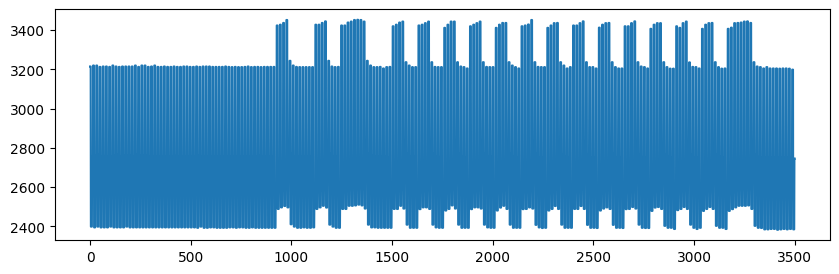

In [19]:
plt.figure(figsize=(10,3))
plt.plot(rx[1500:5000])
plt.show()

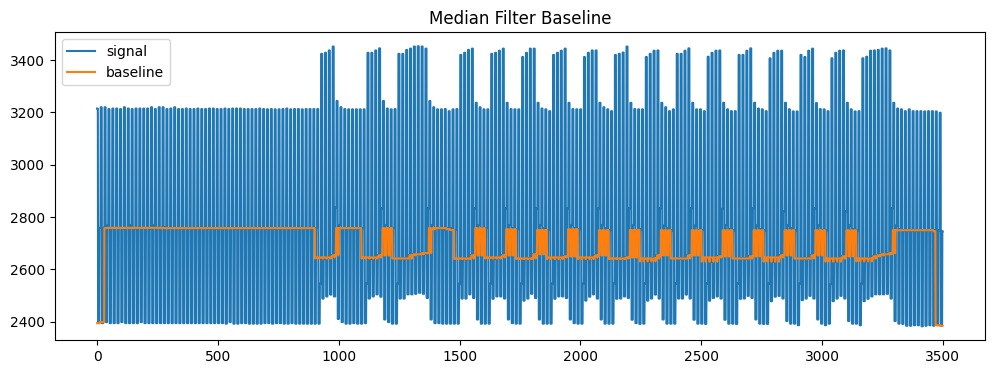

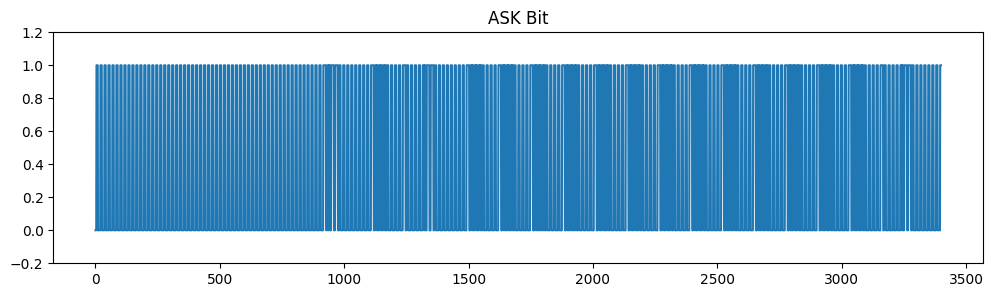

In [48]:
import numpy as np
from scipy.signal import medfilt
import matplotlib.pyplot as plt

signal =rx[1500:5000]

# Median Filtering（baseline）
N = 101
MID = N // 2  
baseline = medfilt(signal, N)

# rx_ask <= ( lpf - (lpf>>5) - (lpf>>8) > raw );
threshold = baseline * 0.988
#threshold = baseline - (baseline // 32) - (baseline // 256)

# center point
raw = np.roll(signal,MID)

# ASK
bit = (raw < threshold).astype(int)

#Delete invalid points
bit = bit[MID : -MID]

plt.figure(figsize=(12,4))
plt.plot(signal, label="signal")
plt.plot(baseline, label="baseline")
plt.legend()
plt.title("Median Filter Baseline")
plt.show()

plt.figure(figsize=(12,3))
plt.plot(bit)
#plt.plot(result)
#plt.xlim(900,1500)
plt.ylim(-0.2, 1.2)
plt.title("ASK Bit")
plt.show()

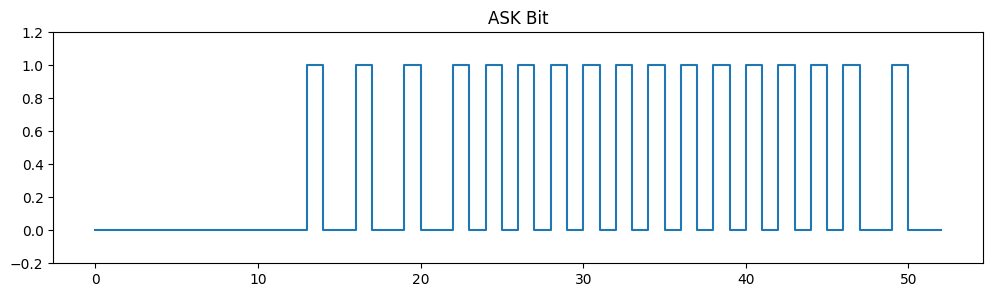

In [50]:
samples_per_bit = 64 
N = len(bit) // samples_per_bit 
bit_trim = bit[:N * samples_per_bit] 
bit_ds = (bit_trim.reshape(N, samples_per_bit).mean(axis=1) > 0.5).astype(int)

plt.figure(figsize=(12,3))
plt.step(range(len(bit_ds)), bit_ds)
#plt.plot(result)
#plt.xlim(900,1500)
plt.ylim(-0.2, 1.2)
plt.title("ASK Bit")
plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import medfilt

Rb = 106e3
fc = 2*Rb
Fs = 13.56e6

# 包络
rectified = np.abs(rx)
order = 5
nyquist = 0.5 * Fs
normal_cutoff = fc / nyquist
b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
envelope = signal.filtfilt(b, a, rectified)

2910.2398569891197
2725.4278184245936


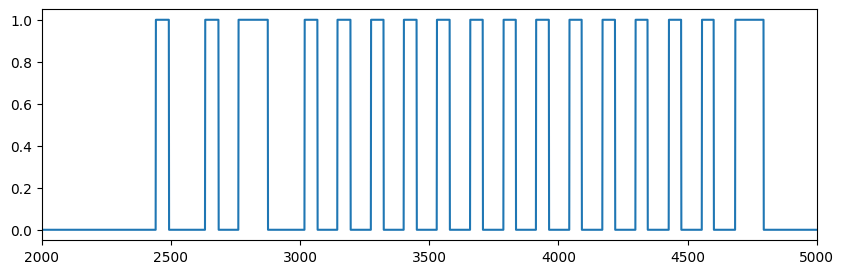

2817.8338377068567


In [12]:
envelope_max = envelope[200:2800].max()
envelope_min = envelope[200:2800].min()
print(envelope_max)
print(envelope_min)

threshold = (envelope_max + envelope_min)/2
bit = (envelope > threshold).astype(int) 

plt.figure(figsize=(10,3))
plt.xlim(2000, 5000)
plt.plot(bit)
plt.show()
print(threshold)

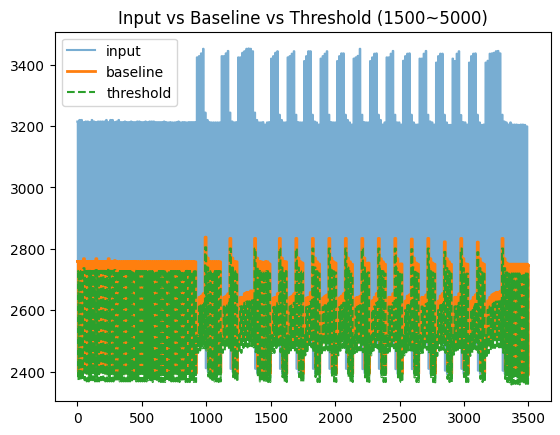

In [13]:
import numpy as np
import matplotlib.pyplot as plt
N       = 21
RAW_IDX = 10  
LPF_IDX = 12

adc = np.array(rx)   

lpf = np.array([np.median(adc[max(0,i-20):i+1]) for i in range(len(adc))])
th  = lpf - (lpf//128) - (lpf//256)   # ≈0.988*lpf

raw = np.array([adc[max(0, i-RAW_IDX)] for i in range(len(adc))])
ask = raw < th
start = 1500
end   = 5000

adc_cut = adc[start:end]
lpf_cut = lpf[start:end]
th_cut  = th[start:end]

plt.plot(adc_cut, label='input', alpha=0.6)
plt.plot(lpf_cut, label='baseline', lw=2)
plt.plot(th_cut,  '--', label='threshold')

plt.legend()
plt.title("Input vs Baseline vs Threshold (1500~5000)")
plt.show()